# DATA5000 Workshop #2 Notebook on Forecasting

# ***NeuralProphet:***

## https://neuralprophet.com/

# ***Presentation***
## https://github.com/ourownstory/neural_prophet/blob/main/notes/NeuralProphet_Introduction.pdf

### ***The research paper:***
## https://arxiv.org/abs/2111.15397

### ***Facebook Prophet***, which set an industry standard for explainable, scalable, and user-friendly forecasting frameworks: https://facebook.github.io/prophet/

### But Prophet is a statistical method - NOT a Neural Network-based Model

### ***Prophet*** also lacks understanding of "local context": which is essential for forecasting the near-term future.

### The lack of local context, which is essential for forecasting the nearterm future, has restricted the usefulness of Prophet in industrial applications.


### ***Readings***:

* https://towardsdatascience.com/in-depth-understanding-of-neuralprophet-through-a-complete-example-2474f675bc96

* https://towardsdatascience.com/prophet-vs-neuralprophet-fc717ab7a9d8


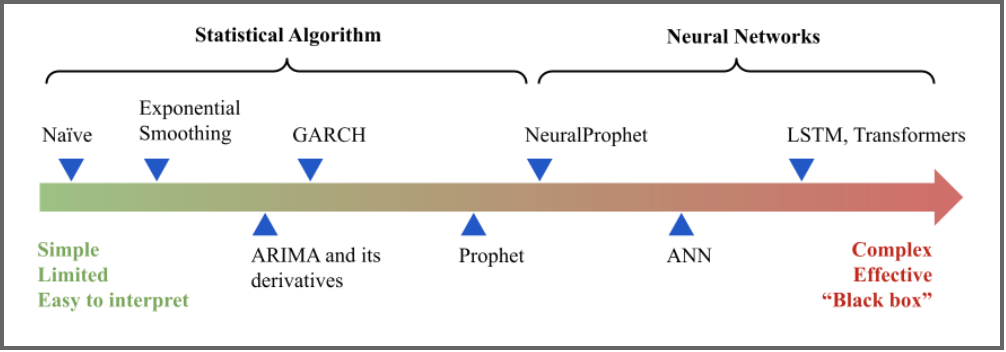

#***LOCAL CONTEXT***

### ***A local context is:*** the near-term future depends on the current state of the system. The majority of time series forecasting exhibits those dynamics, evidenced in scenarios related to energy consumption, traffic patterns, air quality measures, and much more. For example, when there’s a strong uptick in server load, it might have been triggered by a recent event that could continue for prolonged periods, which should be reflected in near-term forecasts.

### For short to medium-term forecasts, NeuralProphet improves forecast accuracy by 55 to 92 percent

## What is a Neural Network? https://www.ibm.com/cloud/learn/neural-networks

# ***TIME IN NEURAL PROPHET***
### Pandas Time Series: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases

#***What is a Neural Network?***
## What is a Neural Network? https://www.ibm.com/cloud/learn/neural-networks

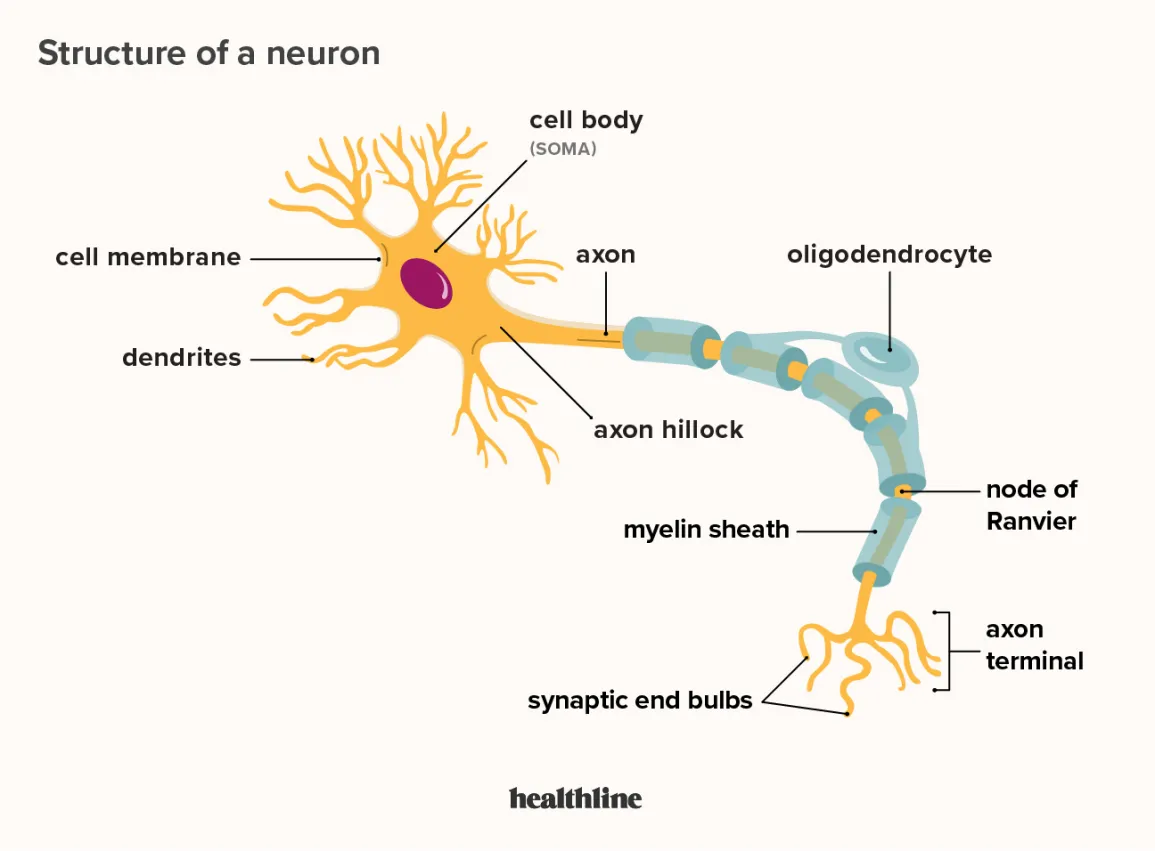

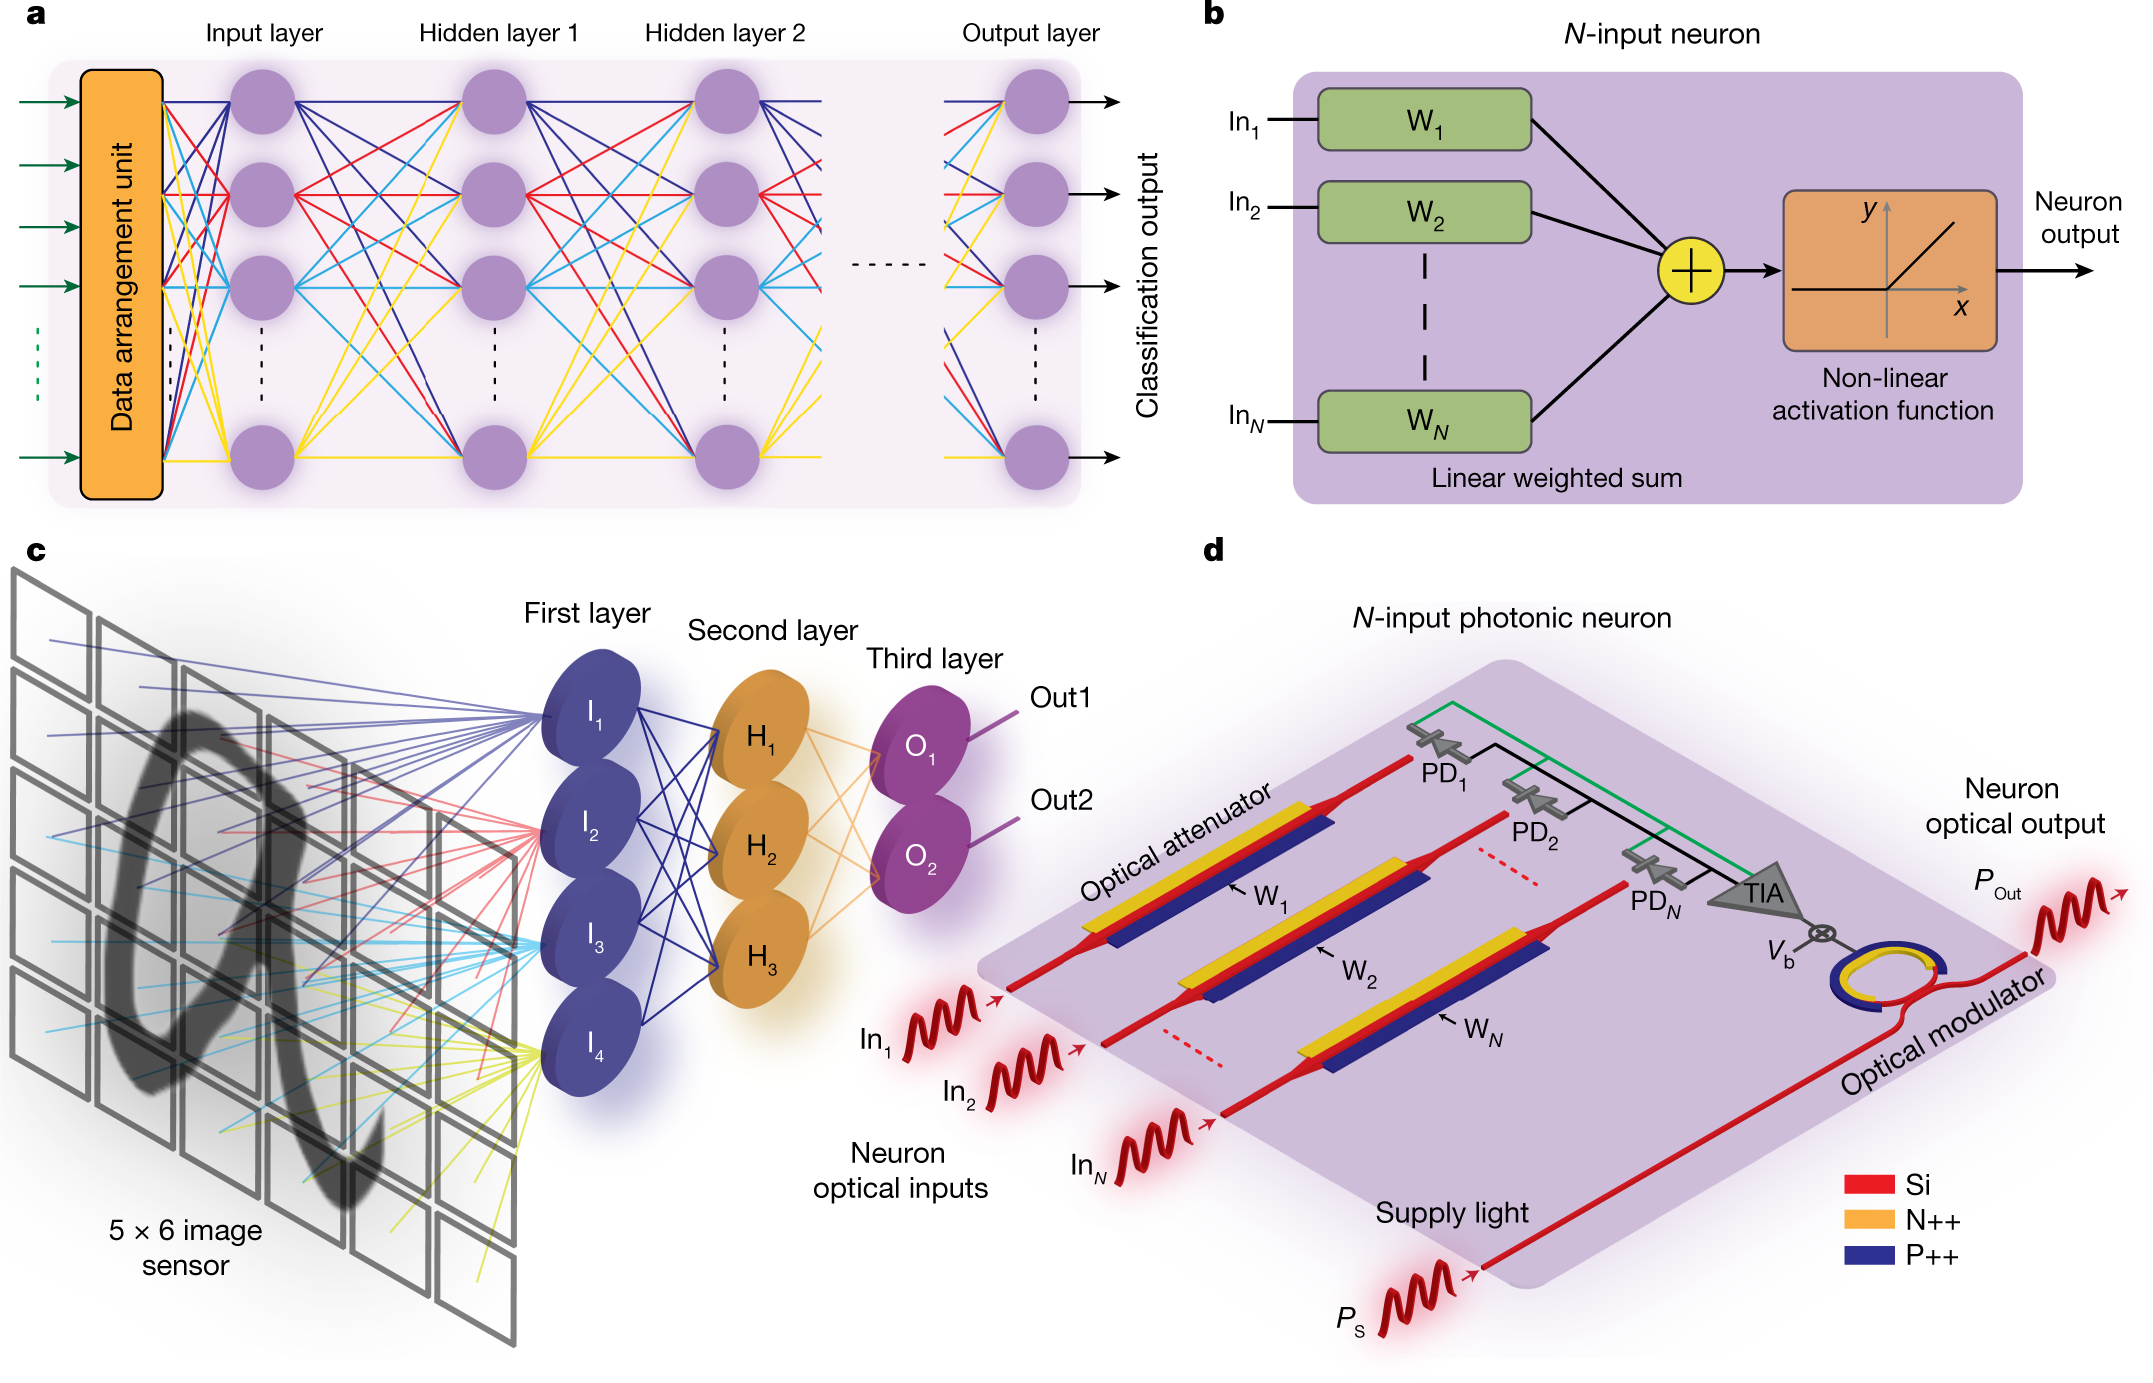

# ***Running NeuralProphet***

In [1]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# STEP 1: Install Libraries

We start by installing everything that won't work with NeuralProphet

In [2]:
!pip uninstall -y tensorflow torch torchvision torchaudio opencv-python numpy opencv-contrib-python opencv-python-headless albucore albumentations dopamine-rl captum numba datasets gcsfs gradio

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: torch 2.3.1+cu121
Uninstalling torch-2.3.1+cu121:
  Successfully uninstalled torch-2.3.1+cu121
Found existing installation: torchvision 0.18.1+cu121
Uninstalling torchvision-0.18.1+cu121:
  Successfully uninstalled torchvision-0.18.1+cu121
Found existing installation: torchaudio 2.3.1+cu121
Uninstalling torchaudio-2.3.1+cu121:
  Successfully uninstalled torchaudio-2.3.1+cu121
Found existing installation: numpy 2.3.5
Uninstalling numpy-2.3.5:
  Successfully uninstalled numpy-2.3.5
Found existing installation: albucore 0.0.24
Uninstalling albucore-0.0.24:
  Successfully uninstalled albucore-0.0.24
Found existing installation: albumentations 2.0.8
Uninstalling albumentations-2.0.8:
  Successfully uninstalled albumentations-2.0.8
Found existing installation: dopamine_rl 4.1.2
Uninstalling dopamine_rl-4.1.2:
  Successfully uninstalled dopam

In [3]:
!pip install --no-cache-dir numpy==1.25.0
!pip install --no-cache-dir --force-reinstall torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 53.9 MB/s  0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'numpy' when getting requirements to build wheel
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 205.0 MB/s  0:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 217.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 290.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 304.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 751.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 342.2 M

In [ ]:
!pip install --no-cache-dir --force-reinstall kaleido==0.2.1

In [3]:
!pip install --no-cache-dir --pre neuralprophet==1.0.0rc10

#if "google.colab" in str(get_ipython()):
#    !pip install git+https://github.com/ourownstory/neural_prophet.git
#    # may take a while
#    #!pip install neuralprophet # much faster, but may not have the latest upgrades/bugfixes

  Cloning https://github.com/ourownstory/neural_prophet.git to /tmp/pip-req-build-ylrxsly7
  Running command git clone --filter=blob:none --quiet https://github.com/ourownstory/neural_prophet.git /tmp/pip-req-build-ylrxsly7
  Resolved https://github.com/ourownstory/neural_prophet.git to commit 5e6b2314547334bbd5dbfc9cc5e019efcb3d67c5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl (79.9 MB)
  Attempting uninstall: kaleido
    Found existing installation: kaleido 1.2.0
    Uninstalling kaleido-1.2.0:
      Successfully uninstalled kaleido-1.2.0


In [5]:
from neuralprophet import __version__


AttributeError: partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)

In [7]:
import torch
torch.__version__

'2.3.1+cu121'

In [4]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 32.1 MB/s  0:00:20
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 29.5 MB/s  0:00:12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 138.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 61.7 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 60.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 36.3 MB/s  0:00:12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 72.3 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 67.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 72.8 MB/s  0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 44.3 MB/s  0:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 29.9 MB/s  0:00:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 80.3 MB/s  0:00:

  Cloning https://github.com/ourownstory/neural_prophet.git to /tmp/pip-req-build-dz7md9j2
  Running command git clone --filter=blob:none --quiet https://github.com/ourownstory/neural_prophet.git /tmp/pip-req-build-dz7md9j2
  Resolved https://github.com/ourownstory/neural_prophet.git to commit 5e6b2314547334bbd5dbfc9cc5e019efcb3d67c5
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached kaleido-0.2.1-py2.py3-none-manylinux1_x86_64.whl.metadata (15 kB)
  Using cached torch-2.3.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadat

In [6]:
!pip install neuralprophet['live']

### Import installed libraries

In [7]:
from neuralprophet import NeuralProphet, set_log_level
set_log_level("ERROR")

AttributeError: module 'torch.library' has no attribute 'register_fake'

In [9]:
import neuralprophet

AttributeError: partially initialized module 'torchvision' has no attribute 'extension' (most likely due to a circular import)

In [ ]:
import pandas as pd
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

#STEP 2: Basic NeuralProphet on Test Data

In [ ]:
data_location = "https://raw.githubusercontent.com/ourownstory/neuralprophet-data/main/datasets/"
df = pd.read_csv(data_location + "wp_log_peyton_manning.csv", dayfirst=True)

In [ ]:
df

,ds,y
0,2007-12-10,9.5908
1,2007-12-11,8.5196
2,2007-12-12,8.1837
3,2007-12-13,8.0725
4,2007-12-14,7.8936
...,...,...
2959,2016-01-16,7.8172
2960,2016-01-17,9.2739
2961,2016-01-18,10.3338
2962,2016-01-19,9.1259


# Create NeuralProphet

In [ ]:
# epochs - how many generations to learn
example_model = NeuralProphet(quantiles=[0.02, 0.98], epochs=10)

# Model training - make sure that the frequency of the time series is correctly coded

In [ ]:
example_model_metrics = example_model.fit(df, freq="D", progress='plot-all')

Finding best initial lr:   0%|          | 0/237 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

In [ ]:
example_model_future = example_model.make_future_dataframe(df, periods=365, n_historic_predictions=True)

In [ ]:
example_model_forecast = example_model.predict(example_model_future)

Predicting: 93it [00:00, ?it/s]

In [ ]:
example_model_forecast

,ds,y,yhat1,yhat1 2.0%,yhat1 98.0%,trend,season_yearly,season_weekly
0,2007-12-10,9.5908,8.193427,7.445043,8.193427,7.428999,0.361948,0.402480
1,2007-12-11,8.5196,7.911122,7.395048,7.911122,7.430025,0.353576,0.127522
2,2007-12-12,8.1837,7.712620,7.296489,7.712620,7.431050,0.346625,-0.065056
3,2007-12-13,8.0725,7.686562,7.235918,7.686562,7.432076,0.341244,-0.086758
4,2007-12-14,7.8936,7.695561,7.234517,7.695561,7.433102,0.337583,-0.075123
...,...,...,...,...,...,...,...,...
3324,2017-01-15,NaN,8.291578,7.749095,13.139505,7.210139,1.043726,0.037714
3325,2017-01-16,NaN,8.670855,7.995295,13.597592,7.209127,1.059195,0.402533
3326,2017-01-17,NaN,8.407617,7.956709,13.221717,7.208116,1.071831,0.127670
3327,2017-01-18,NaN,8.223557,7.865819,13.064976,7.207104,1.081490,-0.065036


import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(example_model_forecast, *['y'], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(example_model_forecast, *['yhat1'], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(example_model_forecast, *['yhat1 2.0%'], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(example_model_forecast, *['yhat1 98.0%'], **{})
chart

...

import numpy as np
from google.colab import autoviz

def scatter_plots(df, colname_pairs, figscale=1, alpha=.8):
  from matplotlib import pyplot as plt
  plt.figure(figsize=(len(colname_pairs) * 6 * figscale, 6 * figscale))
  for plot_i, (x_colname, y_colname) in enumerate(colname_pairs, start=1):
    ax = plt.subplot(1, len(colname_pairs), plot_i)
    df.plot(kind='scatter', x=x_colname, y=y_colname, s=(32 * figscale), alpha=alpha, ax=ax)
    ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = scatter_plots(example_model_forecast, *[[['y', 'yhat1'], ['yhat1', 'yhat1 2.0%'], ['yhat1 2.0%', 'yhat1 98.0%'], ['yhat1 98.0%', 'trend']]], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(example_model_forecast, *['ds', 'y', None], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(example_model_forecast, *['ds', 'yhat1', None], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(example_model_forecast, *['ds', 'yhat1 2.0%', None], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(example_model_forecast, *['ds', 'yhat1 98.0%', None], **{})
chart

# Save forecast data to csv file

In [ ]:
example_model_forecast.to_csv('example_model_neuralprophet_forecast.csv')

# Use Plotly to show chart of forecasts: https://plotly.com/python/setting-graph-size/


In [ ]:
visual_example_model = example_model.plot(example_model_forecast)

In [ ]:
visual_example_model

In [ ]:
import plotly.express as px

In [ ]:
df_vis = example_model_forecast
fig = px.line(df_vis, x="ds", y="yhat1",
                 width=800, height=400)
fig

# ***Forecast on Project Data***

# Forecast Australian Inflation Rate

## Explaination about inflation: https://www.rba.gov.au/education/resources/explainers/inflation-and-its-measurement.html



# STEP 2: Load Data

In [ ]:
df = pd.read_csv('https://s3.ap-southeast-2.wasabisys.com/data5000/aus_cpi.csv', dayfirst=True)

In [ ]:
df

,Date,AU-CPI
0,1/1/1960,2.73973
1,1/4/1960,4.10959
2,1/7/1960,4.05405
3,1/10/1960,4.00000
4,1/1/1961,4.00000
...,...,...
249,1/4/2022,6.14478
250,1/7/2022,7.26817
251,1/10/2022,7.83182
252,1/1/2023,7.02179


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    254 non-null    object 
 1   AU-CPI  254 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.1+ KB


# STEP 3: Pre-process Time Series

In [ ]:
df.Date

,Date
0,1/1/1960
1,1/4/1960
2,1/7/1960
3,1/10/1960
4,1/1/1961
...,...
249,1/4/2022
250,1/7/2022
251,1/10/2022
252,1/1/2023


### Convert Date String to True Datetimes

In [ ]:
df.Date = pd.to_datetime(df.Date, format='%d/%m/%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    254 non-null    datetime64[ns]
 1   AU-CPI  254 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.1 KB


### Make Date the Index of the Dataset

In [ ]:
df = df.set_index(df.Date)

In [ ]:
df

,Date,AU-CPI
Date,,
1960-01-01,1960-01-01,2.73973
1960-01-04,1960-01-04,4.10959
1960-01-07,1960-01-07,4.05405
1960-01-10,1960-01-10,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-01-04,2022-01-04,6.14478
2022-01-07,2022-01-07,7.26817
2022-01-10,2022-01-10,7.83182


In [ ]:
data = df[['Date', 'AU-CPI']]
data

,Date,AU-CPI
Date,,
1960-01-01,1960-01-01,2.73973
1960-01-04,1960-01-04,4.10959
1960-01-07,1960-01-07,4.05405
1960-01-10,1960-01-10,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-01-04,2022-01-04,6.14478
2022-01-07,2022-01-07,7.26817
2022-01-10,2022-01-10,7.83182


In [ ]:
data.rename(columns={"Date":"ds", "AU-CPI":"y"}, inplace=True)

In [ ]:
data

,ds,y
Date,,
1960-01-01,1960-01-01,2.73973
1960-01-04,1960-01-04,4.10959
1960-01-07,1960-01-07,4.05405
1960-01-10,1960-01-10,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-01-04,2022-01-04,6.14478
2022-01-07,2022-01-07,7.26817
2022-01-10,2022-01-10,7.83182


#STEP 4: Forecasting - Neural Network (NeuralProphet)

## Note: do not run the code immediately below - it is here only for reference on the parameters

In [ ]:
# DO NOT RUN - this is put here to show the parameters that are available for adjustment
class neuralprophet.forecaster.NeuralProphet(growth: Literal['off', 'linear', 'discontinuous'] = 'linear',
                                             changepoints: Optional[list] = None,
                                             n_changepoints: int = 10,
                                             changepoints_range: float = 0.8,
                                             trend_reg: float = 0,
                                             trend_reg_threshold: Optional[Union[bool, float]] = False,
                                             trend_global_local: str = 'global',
                                             yearly_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             weekly_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             daily_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             seasonality_mode: Literal['additive', 'multiplicative'] = 'additive',
                                             seasonality_reg: float = 0, season_global_local: Literal['global', 'local'] = 'global',
                                             n_forecasts: int = 1,
                                             n_lags: int = 0,
                                             ar_layers: Optional[list] = [],
                                             ar_reg: Optional[float] = None,
                                             lagged_reg_layers: Optional[list] = [],
                                             learning_rate: Optional[float] = None,
                                             epochs: Optional[int] = None,
                                             batch_size: Optional[int] = None,
                                             loss_func: Union[str, torch.nn.modules.loss._Loss, Callable] = 'Huber',
                                             optimizer: Union[str, Type[torch.optim.optimizer.Optimizer]] = 'AdamW',
                                             newer_samples_weight: float = 2,
                                             newer_samples_start: float = 0.0,
                                             quantiles: List[float] = [],
                                             impute_missing: bool = True,
                                             impute_linear: int = 10,
                                             impute_rolling: int = 10,
                                             drop_missing: bool = False,
                                             collect_metrics: Union[List[str], bool, Dict[str, torchmetrics.metric.Metric]] = True,
                                             normalize: Literal['auto', 'soft', 'soft1', 'minmax', 'standardize', 'off'] = 'auto',
                                             global_normalization: bool = False,
                                             global_time_normalization: bool = True,
                                             unknown_data_normalization: bool = False,
                                             accelerator: Optional[str] = None,
                                             trainer_config: dict = {},
                                             prediction_frequency: Optional[dict] = None)

### ADAM optimiser https://keras.io/api/optimizers/adam/

In [ ]:
aus_cpi_model = NeuralProphet(
    epochs = 100,
    loss_func = "Huber",
    optimizer = "AdamW"
)

In [ ]:
# Use static plotly in notebooks
aus_cpi_model.set_plotting_backend("plotly-static")

### Split data into training and validation

In [ ]:
# note the code for the frequency of the time series
df_train, df_val = aus_cpi_model.split_df(data, valid_p = 0.20, freq='Q')

In [ ]:
df_train

,ds,y
Date,,
1960-01-01,1960-01-01,2.73973
1960-01-04,1960-01-04,4.10959
1960-01-07,1960-01-07,4.05405
1960-01-10,1960-01-10,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2009-01-10,2009-01-10,2.05628
2010-01-01,2010-01-01,2.91892
2010-01-04,2010-01-04,3.12164


In [ ]:
# plot
fig_df_train = px.line(df_train, x="ds", y="y",
                 width=800, height=400)
fig_df_train

# Validation data is used by NeuralProphet to measure its performance and make adjustments to parameters.

In [ ]:
df_val

,ds,y
Date,,
2011-01-01,2011-01-01,3.25630
2011-01-04,2011-01-04,3.54906
2011-01-07,2011-01-07,3.41969
2011-01-10,2011-01-10,2.99278
2012-01-01,2012-01-01,1.62767
2012-01-04,2012-01-04,1.20968
2012-01-07,2012-01-07,2.00401
2012-01-10,2012-01-10,2.20441
2013-01-01,2013-01-01,2.50250


### Training

In [ ]:
aus_cpi_metrics = aus_cpi_model.fit(df_train, validation_df=df_val, progress='plot-all')

Finding best initial lr:   0%|          | 0/212 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

In [ ]:
aus_cpi_metrics

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,MAE,RMSE,Loss,RegLoss
0,10.717373,13.114659,0.370186,0.0,0,19.442207,22.063017,0.613372,0.0
1,10.555820,12.896206,0.359406,0.0,1,19.315460,22.124104,0.607766,0.0
2,10.301929,12.543524,0.342349,0.0,2,18.918612,21.692715,0.589689,0.0
3,9.916883,12.004103,0.316921,0.0,3,18.450413,21.254219,0.568619,0.0
4,9.424645,11.269587,0.283608,0.0,4,17.623005,20.530283,0.531824,0.0
...,...,...,...,...,...,...,...,...,...
95,1.271151,1.805478,0.007693,0.0,95,2.684888,3.309776,0.017043,0.0
96,1.272139,1.805556,0.007694,0.0,96,2.672457,3.324682,0.016860,0.0
97,1.272324,1.805573,0.007694,0.0,97,2.681158,3.330603,0.016943,0.0
98,1.272443,1.805555,0.007694,0.0,98,2.665202,3.280367,0.016785,0.0


In [ ]:
aus_cpi_metrics.to_csv('aus_cpi_metrics.csv')

# Forecasting

## We shall forecast 2 quarters into the future

In [ ]:
aus_cpi_future_time = aus_cpi_model.make_future_dataframe(df=data, n_historic_predictions=True, periods=365)

In [ ]:
aus_cpi_future_time

,ds,y
0,1960-01-01,2.73973
1,1960-01-04,4.10959
2,1960-01-07,4.05405
3,1960-01-10,4.00000
4,1961-01-01,4.00000
...,...,...
614,2025-12-22,NaN
615,2025-12-25,NaN
616,2025-12-28,NaN
617,2025-12-31,NaN


In [ ]:
aus_cpi_forecast = aus_cpi_model.predict(df=aus_cpi_future_time)

Predicting: 13it [00:00, ?it/s]

In [ ]:
aus_cpi_forecast

,ds,y,yhat1,trend,season_yearly,season_weekly
0,1960-01-01,2.73973,7.418993,21.729172,-14.237179,-0.073000
1,1960-01-04,4.10959,6.895843,21.727982,-14.998358,0.166219
2,1960-01-07,4.05405,6.796269,21.726793,-15.100097,0.169573
3,1960-01-10,4.00000,6.820265,21.725603,-14.586423,-0.318915
4,1961-01-01,4.00000,6.775520,21.584023,-14.489593,-0.318911
...,...,...,...,...,...,...
614,2025-12-22,NaN,9.073540,16.881454,-7.973942,0.166029
615,2025-12-25,NaN,6.581928,16.881107,-10.468538,0.169359
616,2025-12-28,NaN,4.025327,16.880760,-12.536569,-0.318864
617,2025-12-31,NaN,2.860099,16.880413,-14.046782,0.026468


import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(aus_cpi_forecast, *['y'], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(aus_cpi_forecast, *['yhat1'], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(aus_cpi_forecast, *['trend'], **{})
chart

import numpy as np
from google.colab import autoviz

def value_plot(df, y, figscale=1):
  from matplotlib import pyplot as plt
  df[y].plot(kind='line', figsize=(8 * figscale, 4 * figscale), title=y)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = value_plot(aus_cpi_forecast, *['season_yearly'], **{})
chart

...

import numpy as np
from google.colab import autoviz

def scatter_plots(df, colname_pairs, figscale=1, alpha=.8):
  from matplotlib import pyplot as plt
  plt.figure(figsize=(len(colname_pairs) * 6 * figscale, 6 * figscale))
  for plot_i, (x_colname, y_colname) in enumerate(colname_pairs, start=1):
    ax = plt.subplot(1, len(colname_pairs), plot_i)
    df.plot(kind='scatter', x=x_colname, y=y_colname, s=(32 * figscale), alpha=alpha, ax=ax)
    ax.spines[['top', 'right',]].set_visible(False)
  plt.tight_layout()
  return autoviz.MplChart.from_current_mpl_state()

chart = scatter_plots(aus_cpi_forecast, *[[['y', 'yhat1'], ['yhat1', 'trend'], ['trend', 'season_yearly'], ['season_yearly', 'season_weekly']]], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(aus_cpi_forecast, *['ds', 'y', None], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(aus_cpi_forecast, *['ds', 'yhat1', None], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(aus_cpi_forecast, *['ds', 'trend', None], **{})
chart

import numpy as np
from google.colab import autoviz

def time_series_multiline(df, timelike_colname, value_colname, series_colname, figscale=1, mpl_palette_name='Dark2'):
  from matplotlib import pyplot as plt
  import seaborn as sns
  figsize = (10 * figscale, 5.2 * figscale)
  palette = list(sns.palettes.mpl_palette(mpl_palette_name))
  def _plot_series(series, series_name, series_index=0):
    if value_colname == 'count()':
      counted = (series[timelike_colname]
                 .value_counts()
                 .reset_index(name='counts')
                 .rename({'index': timelike_colname}, axis=1)
                 .sort_values(timelike_colname, ascending=True))
      xs = counted[timelike_colname]
      ys = counted['counts']
    else:
      xs = series[timelike_colname]
      ys = series[value_colname]
    plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

  fig, ax = plt.subplots(figsize=figsize, layout='constrained')
  df = df.sort_values(timelike_colname, ascending=True)
  if series_colname:
    for i, (series_name, series) in enumerate(df.groupby(series_colname)):
      _plot_series(series, series_name, i)
    fig.legend(title=series_colname, bbox_to_anchor=(1, 1), loc='upper left')
  else:
    _plot_series(df, '')
  sns.despine(fig=fig, ax=ax)
  plt.xlabel(timelike_colname)
  plt.ylabel(value_colname)
  return autoviz.MplChart.from_current_mpl_state()

chart = time_series_multiline(aus_cpi_forecast, *['ds', 'season_yearly', None], **{})
chart

In [ ]:
aus_cpi_forecast.to_csv('aus_cpi_forecast_neuralprophet.csv')

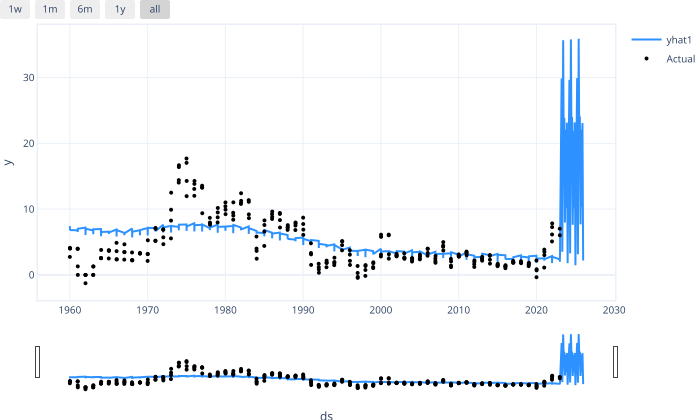

In [ ]:
aus_cpi_forecast_visual = aus_cpi_model.plot(aus_cpi_forecast)

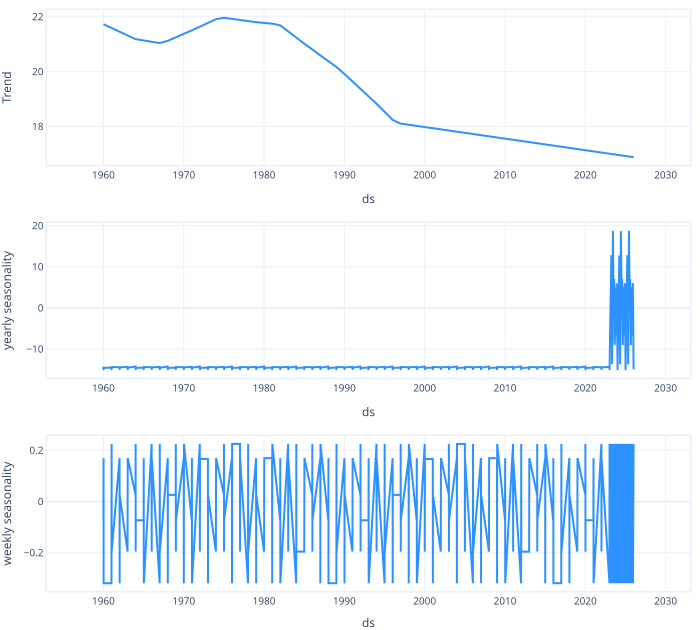

In [ ]:
trends_seasons = aus_cpi_model.plot_components(aus_cpi_forecast)

# Using External Regressors - next time we perform causal analysis